In [ ]:

import numpy as np 
import pandas as pd 


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from pathlib import Path

print('Ready.')

Ready.


In [ ]:

GOOD_IMAGE = '/kaggle/input/datasets/vidishagar/liftup/868A0384.JPG'
BAD_IMAGE  = '/kaggle/input/datasets/vidishagar/liftup/868A0383.JPG'
OUTPUT_DIR = '/kaggle/working'

# Anchor region in GOOD image — a stable component that appears in both images
# Used to compute the pixel offset between the two photos
# → The large 20-pin IC (U3) works well here
# Format: [y1, y2, x1, x2]
ANCHOR_Y1, ANCHOR_Y2 = 250, 380
ANCHOR_X1, ANCHOR_X2 = 740, 930

# Component of interest in GOOD image — the one you want to check for liftup
# Center pixel coordinates
COMP_CX, COMP_CY = 520, 430
COMP_PAD = 130    # pixels around center to extract

# Detection threshold
SSIM_THRESHOLD = 0.55   # below this = DEFECTIVE
DIFF_THRESHOLD = 30     # pixel difference threshold (0-255)
MIN_DEFECT_AREA = 200   # minimum contour area to count as a defect region
# ═══════════════════════════════════════════════════

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print('Config loaded.')

Config loaded.


Good: 1164x722
Bad : 1303x713


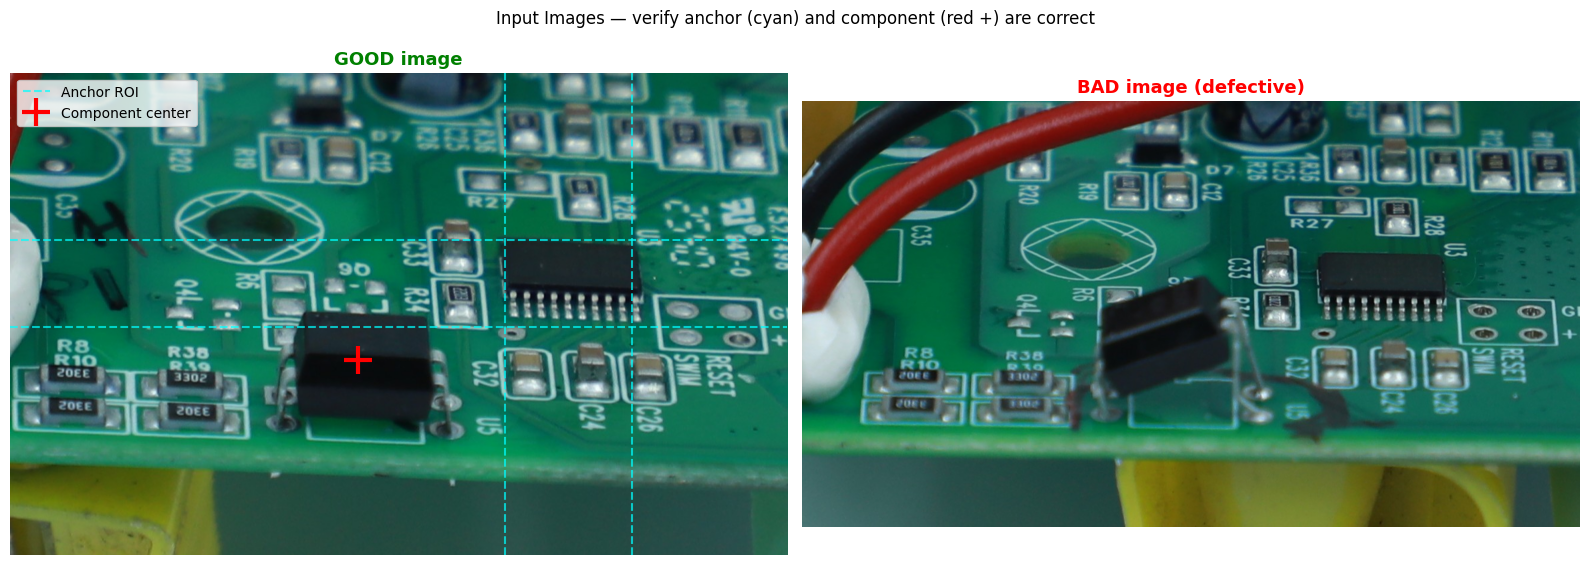

If the cyan box is NOT on a stable component, adjust ANCHOR_* in Cell 2.
If the red + is NOT on the lifted component, adjust COMP_CX/COMP_CY in Cell 2.


In [27]:
good = cv2.imread(GOOD_IMAGE)
bad  = cv2.imread(BAD_IMAGE)
assert good is not None, f'Cannot read: {GOOD_IMAGE}'
assert bad  is not None, f'Cannot read: {BAD_IMAGE}'

print(f'Good: {good.shape[1]}x{good.shape[0]}')
print(f'Bad : {bad.shape[1]}x{bad.shape[0]}')

fig, axes = plt.subplots(1,2,figsize=(16,6))
axes[0].imshow(cv2.cvtColor(good, cv2.COLOR_BGR2RGB))
axes[0].set_title('GOOD image', color='green', fontweight='bold', fontsize=13)
axes[0].axhline(ANCHOR_Y1, color='cyan',  linestyle='--', alpha=0.7, label='Anchor ROI')
axes[0].axhline(ANCHOR_Y2, color='cyan',  linestyle='--', alpha=0.7)
axes[0].axvline(ANCHOR_X1, color='cyan',  linestyle='--', alpha=0.7)
axes[0].axvline(ANCHOR_X2, color='cyan',  linestyle='--', alpha=0.7)
axes[0].plot(COMP_CX, COMP_CY, 'r+', markersize=20, markeredgewidth=3, label='Component center')
axes[0].legend(fontsize=10)
axes[1].imshow(cv2.cvtColor(bad, cv2.COLOR_BGR2RGB))
axes[1].set_title('BAD image (defective)', color='red', fontweight='bold', fontsize=13)
for ax in axes: ax.axis('off')
plt.suptitle('Input Images — verify anchor (cyan) and component (red +) are correct',
             fontsize=12)
plt.tight_layout()
plt.show()
print('If the cyan box is NOT on a stable component, adjust ANCHOR_* in Cell 2.')
print('If the red + is NOT on the lifted component, adjust COMP_CX/COMP_CY in Cell 2.')

In [28]:
good_g = cv2.cvtColor(good, cv2.COLOR_BGR2GRAY)
bad_g  = cv2.cvtColor(bad,  cv2.COLOR_BGR2GRAY)

# Extract anchor template from good image
anchor_template = good_g[ANCHOR_Y1:ANCHOR_Y2, ANCHOR_X1:ANCHOR_X2]
th, tw = anchor_template.shape

# Find anchor in bad image
result = cv2.matchTemplate(bad_g, anchor_template, cv2.TM_CCOEFF_NORMED)
_, conf, _, loc = cv2.minMaxLoc(result)

good_anchor_cx = ANCHOR_X1 + tw//2
good_anchor_cy = ANCHOR_Y1 + th//2
bad_anchor_cx  = loc[0]    + tw//2
bad_anchor_cy  = loc[1]    + th//2

dx = bad_anchor_cx - good_anchor_cx
dy = bad_anchor_cy - good_anchor_cy

print(f'Anchor match confidence : {conf:.3f}  (>0.6 is reliable)')
print(f'Pixel offset            : dx={dx}  dy={dy}')

if conf < 0.5:
    print('WARNING: Low confidence. Try a different anchor region.')
    print('  Pick a large, distinctive component visible in both images.')

# Compute component location in bad image
comp_cx_bad = COMP_CX + dx
comp_cy_bad = COMP_CY + dy
print(f'\nComponent in good: ({COMP_CX}, {COMP_CY})')
print(f'Component in bad : ({comp_cx_bad}, {comp_cy_bad})')

Anchor match confidence : 0.856  (>0.6 is reliable)
Pixel offset            : dx=128  dy=-2

Component in good: (520, 430)
Component in bad : (648, 428)


Patch size: 260x260


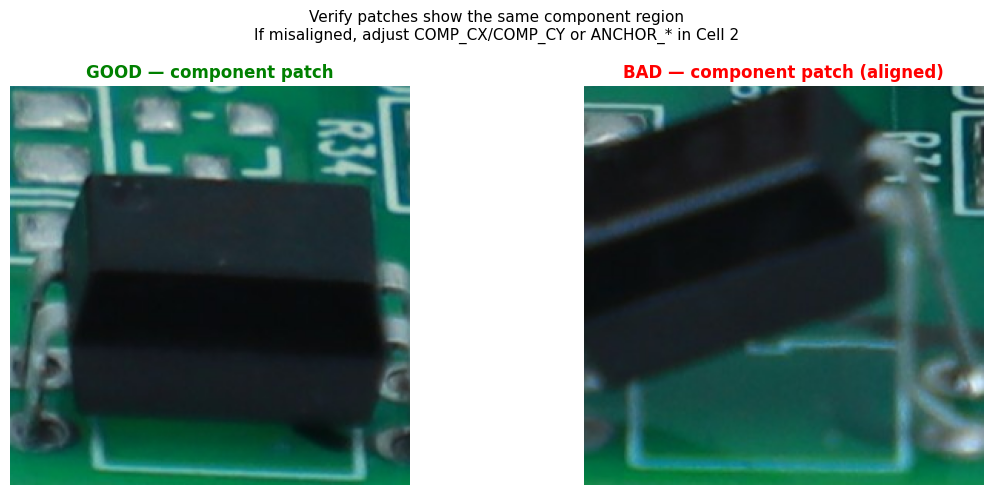

In [29]:
# Extract same-size patches centered on the component
P = COMP_PAD
gp = good[COMP_CY-P:COMP_CY+P, COMP_CX-P:COMP_CX+P]
bp = bad[comp_cy_bad-P:comp_cy_bad+P, comp_cx_bad-P:comp_cx_bad+P]
bp = cv2.resize(bp, (gp.shape[1], gp.shape[0]))

print(f'Patch size: {gp.shape[1]}x{gp.shape[0]}')

fig, axes = plt.subplots(1,2,figsize=(12,5))
axes[0].imshow(cv2.cvtColor(gp, cv2.COLOR_BGR2RGB))
axes[0].set_title('GOOD — component patch', color='green', fontweight='bold', fontsize=12)
axes[1].imshow(cv2.cvtColor(bp, cv2.COLOR_BGR2RGB))
axes[1].set_title('BAD — component patch (aligned)', color='red', fontweight='bold', fontsize=12)
for ax in axes: ax.axis('off')
plt.suptitle('Verify patches show the same component region\n'
             'If misaligned, adjust COMP_CX/COMP_CY or ANCHOR_* in Cell 2',
             fontsize=11)
plt.tight_layout()
plt.show()

In [30]:
def hist_match(src, ref):
    """Match brightness/contrast of src to ref — removes lighting differences."""
    out = np.zeros_like(src)
    for c in range(3):
        s_hist, _ = np.histogram(src[:,:,c].ravel(), 256, [0,256])
        r_hist, _ = np.histogram(ref[:,:,c].ravel(), 256, [0,256])
        s_cdf = s_hist.cumsum() / s_hist.sum()
        r_cdf = r_hist.cumsum() / r_hist.sum()
        lut = np.zeros(256, dtype=np.uint8)
        r_idx = 0
        for s_idx in range(256):
            while r_idx < 255 and r_cdf[r_idx] < s_cdf[s_idx]:
                r_idx += 1
            lut[s_idx] = r_idx
        out[:,:,c] = lut[src[:,:,c]]
    return out

# Match brightness
bp_matched = hist_match(bp, gp)

# Subtract
gp_g = cv2.cvtColor(gp,         cv2.COLOR_BGR2GRAY)
bp_g = cv2.cvtColor(bp_matched, cv2.COLOR_BGR2GRAY)
diff = cv2.absdiff(gp_g, bp_g)

# SSIM score
score, _ = ssim(gp_g, bp_g, full=True)
print(f'SSIM on component patch: {score:.3f}')
print(f'Threshold              : {SSIM_THRESHOLD}')
print(f'SSIM verdict           : {"DEFECTIVE" if score < SSIM_THRESHOLD else "GOOD"}')

# Threshold diff map
_, thresh = cv2.threshold(diff, DIFF_THRESHOLD, 255, cv2.THRESH_BINARY)
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN,   k, iterations=1)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_DILATE, k, iterations=2)

cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
boxes = [(cv2.boundingRect(c), cv2.contourArea(c))
         for c in cnts if cv2.contourArea(c) > MIN_DEFECT_AREA]
boxes.sort(key=lambda x: -x[1])

print(f'\nChanged regions: {len(boxes)}')
for i, ((x,y,w,h), area) in enumerate(boxes[:5]):
    print(f'  [{i+1}] x={x} y={y} w={w} h={h} area={area:.0f}')

# Final verdict combines both signals
verdict = 'DEFECTIVE — COMPONENT LIFTUP' \
    if (score < SSIM_THRESHOLD or len(boxes) > 0) else 'GOOD'
print(f'\nFinal verdict: {verdict}')

SSIM on component patch: 0.342
Threshold              : 0.55
SSIM verdict           : DEFECTIVE

Changed regions: 1
  [1] x=0 y=0 w=260 h=260 area=60298

Final verdict: DEFECTIVE — COMPONENT LIFTUP


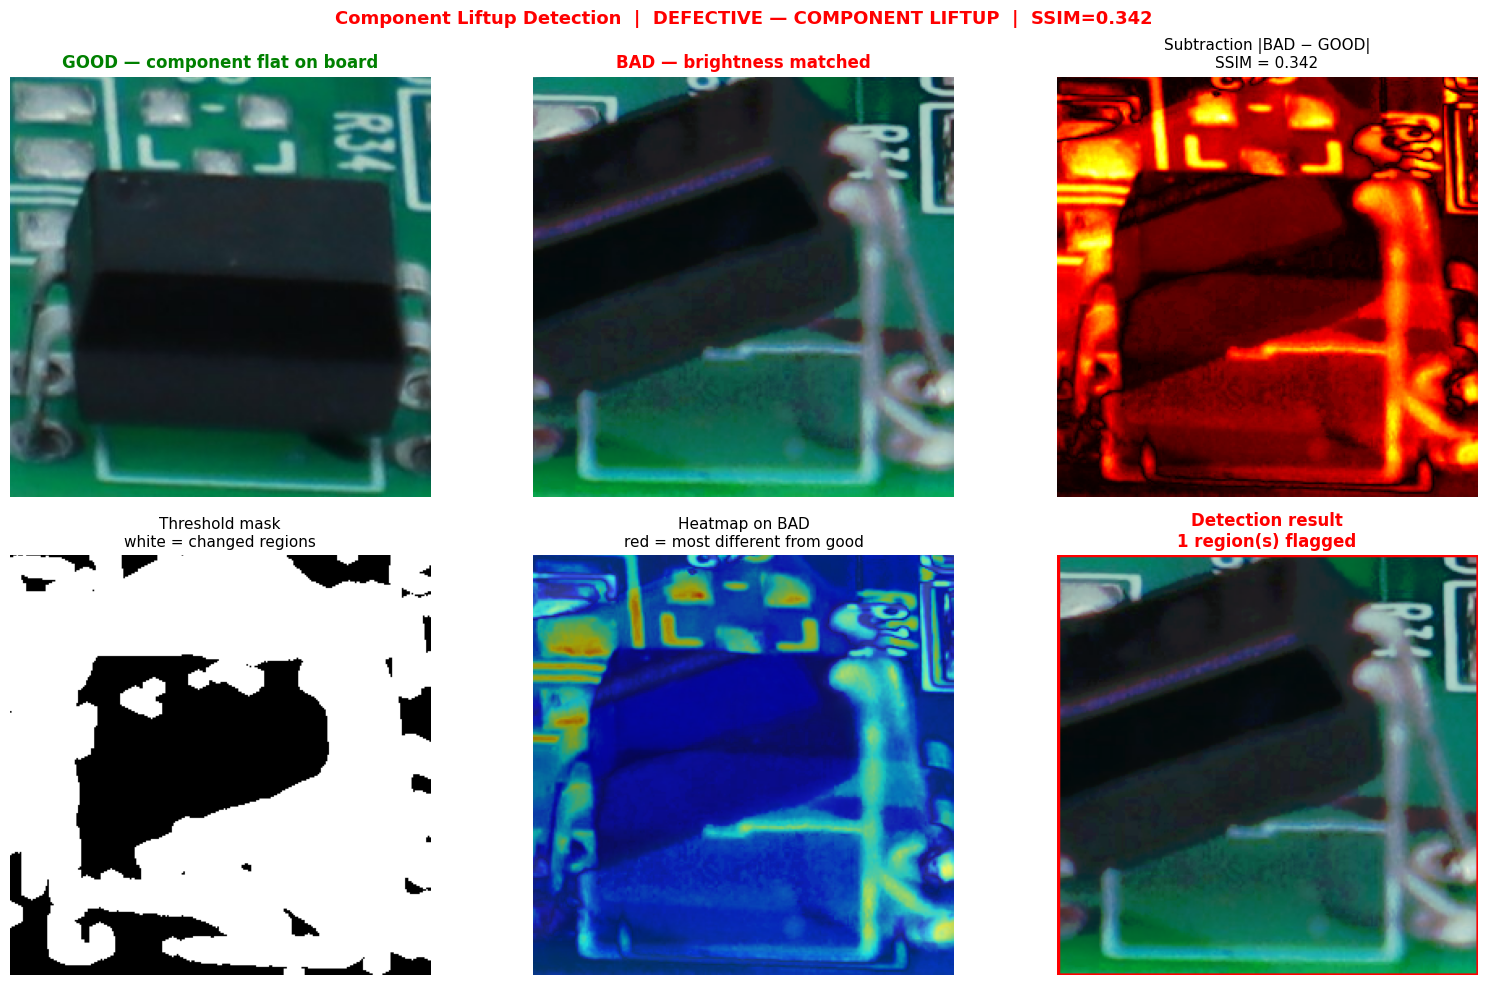

Saved: /kaggle/working/liftup_detection_result.png


In [31]:
# Annotate
ann = bp_matched.copy()
for i, ((x,y,w,h), area) in enumerate(boxes):
    cv2.rectangle(ann,(x,y),(x+w,y+h),(0,0,255),2)
    if i == 0:
        cv2.putText(ann,'LIFTUP',(x, max(0,y-8)),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,0,255),2)

hm      = cv2.applyColorMap(diff, cv2.COLORMAP_JET)
overlay = cv2.addWeighted(bp,0.4,hm,0.6,0)

fig, axes = plt.subplots(2,3,figsize=(16,10))
axes[0,0].imshow(cv2.cvtColor(gp,         cv2.COLOR_BGR2RGB))
axes[0,0].set_title('GOOD — component flat on board',
                     color='green', fontweight='bold', fontsize=12)

axes[0,1].imshow(cv2.cvtColor(bp_matched, cv2.COLOR_BGR2RGB))
axes[0,1].set_title('BAD — brightness matched',
                     color='red',   fontweight='bold', fontsize=12)

axes[0,2].imshow(diff, cmap='hot')
axes[0,2].set_title(f'Subtraction |BAD − GOOD|\nSSIM = {score:.3f}', fontsize=11)

axes[1,0].imshow(thresh, cmap='gray')
axes[1,0].set_title('Threshold mask\nwhite = changed regions', fontsize=11)

axes[1,1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[1,1].set_title('Heatmap on BAD\nred = most different from good', fontsize=11)

axes[1,2].imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
axes[1,2].set_title(f'Detection result\n{len(boxes)} region(s) flagged',
                     fontsize=12, fontweight='bold',
                     color='red' if 'DEFECTIVE' in verdict else 'green')

for ax in axes.flatten(): ax.axis('off')

plt.suptitle(
    f'Component Liftup Detection  |  {verdict}  |  SSIM={score:.3f}',
    fontsize=13, fontweight='bold',
    color='red' if 'DEFECTIVE' in verdict else 'green'
)
plt.tight_layout()
out_path = f'{OUTPUT_DIR}/liftup_detection_result.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')